In [89]:
import matplotlib.pyplot as plt
import numpy as np
from scipy.integrate import solve_ivp

In [90]:
# Solving more than one equation at a time
def solve_seir(t, y, beta, sigma, gamma):
    # Assigning the number of each compartment
    s = y[0]
    e = y[1]
    i = y[2]
    r = y[3]

    # Solving equations 7-10 from assessment brief
    dsdt = -beta * i * s
    dedt = (beta * i * s) - (sigma * e)
    didt = (sigma * e) - (gamma * i)
    drdt = gamma * i

    return dsdt, dedt, didt, drdt

In [91]:
# Verifying that the function is working
# The given initial conditions
y0 = [0.99, 0.01, 0.0, 0.0]
times = np.linspace(0, 100, 1000)

# Given parameters values
beta = 1
sigma = 1
gamma = 0.1

# Solve IVP
sol = solve_ivp(solve_seir, [0, 100], y0, args=(beta, sigma, gamma), t_eval=times)

In [92]:
# Will be used later
infected_R = {}
infected_sig = {}

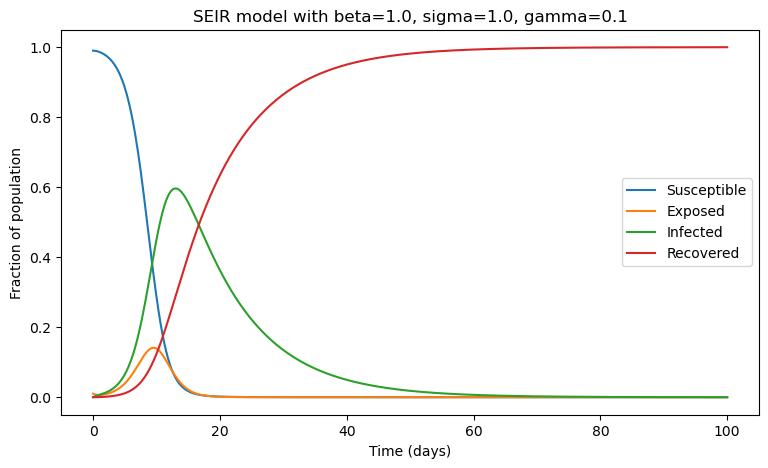

In [93]:
# Solutions
s = sol.y[0]
e = sol.y[1]
i = sol.y[2]
r = sol.y[3]
t = sol.t

# R_0 approx 10
infected_R['10.0'] = i

# Sigma = 1
infected_sig['1'] = i

# Plot the graph to verify
plt.figure(1, figsize=(9, 5))
plt.plot(t, s, label='Susceptible')
plt.plot(t, e, label='Exposed')
plt.plot(t, i, label='Infected')
plt.plot(t, r, label='Recovered')

plt.xlabel('Time (days)')
plt.ylabel('Fraction of population')
plt.title('SEIR model with beta=1.0, sigma=1.0, gamma=0.1')
plt.legend()
plt.show()

In [94]:
total = s + e + i + r
np.unique(total)

array([1., 1., 1., 1.])

The graph looks pretty much the same so it's safe to say that the function is working properly. I will now try different combination of initial values.

I will be specifically looking at equation 11.
$$ R_0 = \frac{\beta}{\gamma}s_0 $$

As mentioned in the brief, "when $R_0 < 1$, we expect any infections to quickly decay to zero. On the other hand, when $R_0 > 1$, we anticipate the outbreak will rise to some peak before finally decaying when most of the population have been infected." So, I will verify the assumptions and experiment with different combination of parameters.

For $R_0 < 1$, $\gamma > \beta$

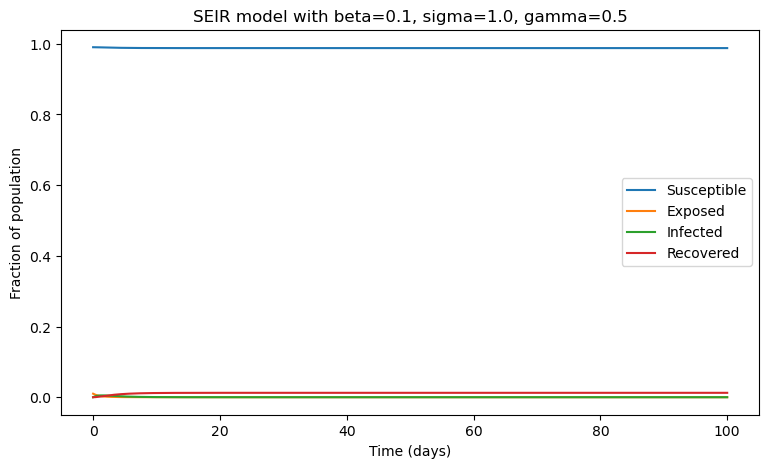

In [95]:
beta = 0.1
sigma = 1.0
gamma = 0.5

# Using the same y0 and times
sol = solve_ivp(solve_seir, [0, 100], y0, args=(beta, sigma, gamma), t_eval=times)

# Plotting the graph
s = sol.y[0]
e = sol.y[1]
i = sol.y[2]
r = sol.y[3]
t = sol.t

# R_0 approx 0.25 < 1
infected_R['0.25'] = i

# Plot the graph to verify
plt.figure(2, figsize=(9, 5))
plt.plot(t, s, label='Susceptible')
plt.plot(t, e, label='Exposed')
plt.plot(t, i, label='Infected')
plt.plot(t, r, label='Recovered')

plt.xlabel('Time (days)')
plt.ylabel('Fraction of population')
plt.title('SEIR model with beta=0.1, sigma=1.0, gamma=0.5')
plt.legend()
plt.show()


For $R_0 \approx 1$, $\beta \approx \gamma$

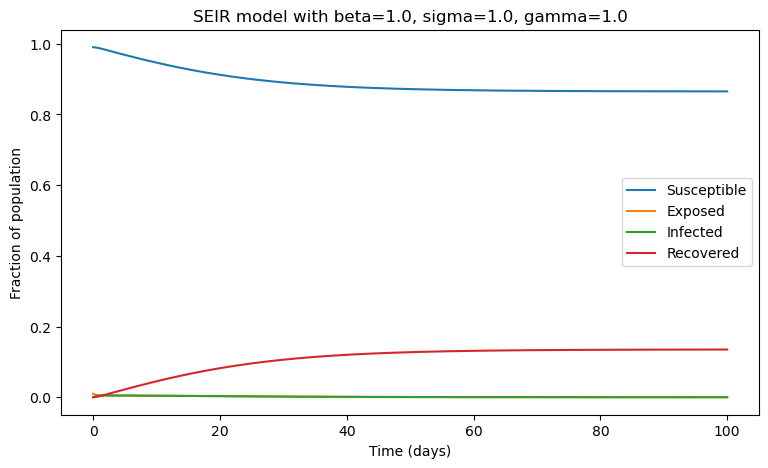

In [96]:
beta = 1.0
sigma = 1.0
gamma = 1.0

# Using the same y0 and times
sol = solve_ivp(solve_seir, [0, 100], y0, args=(beta, sigma, gamma), t_eval=times)

# Plotting the graph
s = sol.y[0]
e = sol.y[1]
i = sol.y[2]
r = sol.y[3]
t = sol.t

# R_0 approx 1
infected_R['1.0'] = i

# Plot the graph to verify
plt.figure(3, figsize=(9, 5))
plt.plot(t, s, label='Susceptible')
plt.plot(t, e, label='Exposed')
plt.plot(t, i, label='Infected')
plt.plot(t, r, label='Recovered')

plt.xlabel('Time (days)')
plt.ylabel('Fraction of population')
plt.title('SEIR model with beta=1.0, sigma=1.0, gamma=1.0')
plt.legend()
plt.show()


For $R_0 > 1$, $\gamma < \beta$

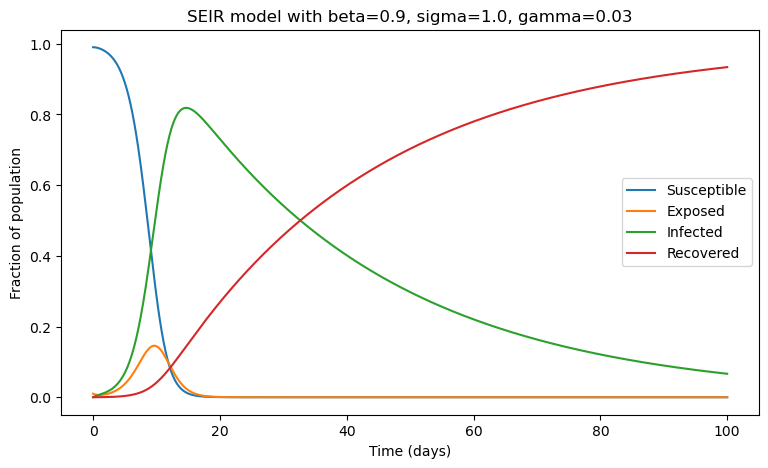

In [97]:
beta = 0.9
sigma = 1.0
gamma = 0.03

# Using the same y0 and times
sol = solve_ivp(solve_seir, [0, 100], y0, args=(beta, sigma, gamma), t_eval=times)

# Plotting the graph
s = sol.y[0]
e = sol.y[1]
i = sol.y[2]
r = sol.y[3]
t = sol.t

# R_0 approx 30
infected_R['30.0'] = i

# Plot the graph to verify
plt.figure(4, figsize=(9, 5))
plt.plot(t, s, label='Susceptible')
plt.plot(t, e, label='Exposed')
plt.plot(t, i, label='Infected')
plt.plot(t, r, label='Recovered')

plt.xlabel('Time (days)')
plt.ylabel('Fraction of population')
plt.title('SEIR model with beta=0.9, sigma=1.0, gamma=0.03')
plt.legend()
plt.show()


To clearly see the effect of $R_0$ on the outbreak, plotting only the infected between different values of $\beta$ and $\gamma$ should help.

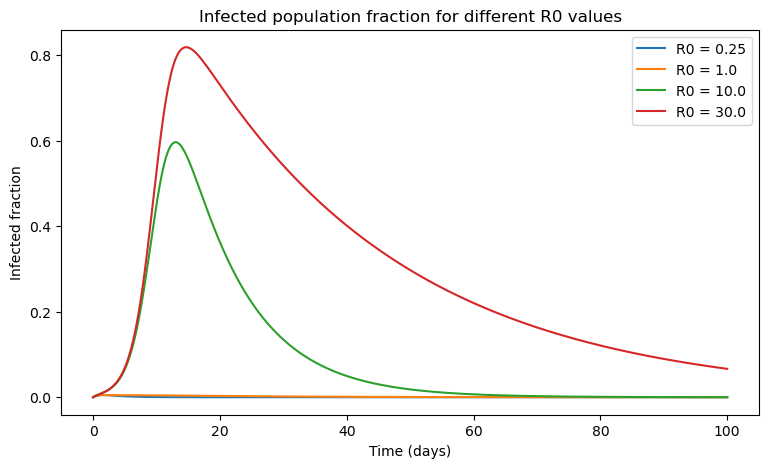

In [98]:
plt.figure(5, figsize=(9, 5))

for key in sorted(infected_R, key=float):
    plt.plot(t, infected_R[key], label=f"R0 = {key}")

plt.xlabel("Time (days)")
plt.ylabel("Infected fraction")
plt.title("Infected population fraction for different R0 values")
plt.legend()
plt.show()

From here, investigating the recovery rate $\gamma$ look like a reasonable next step. Keeping $\beta$ and $\sigma$ fixed, we have:

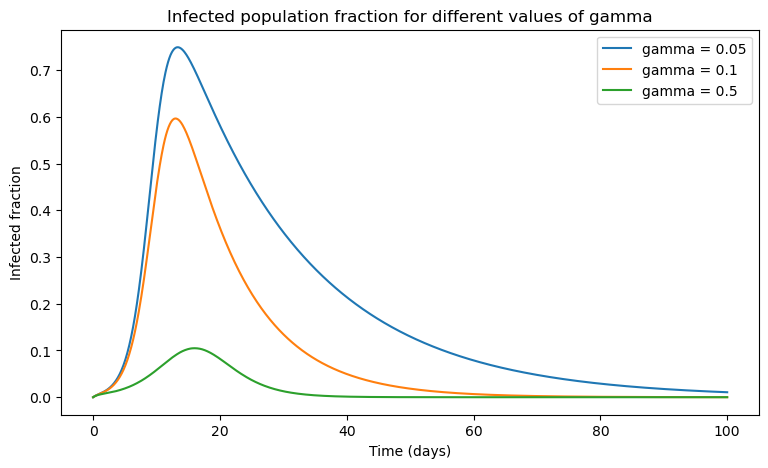

In [99]:
# Fixed parameters
beta = 1.0
sigma = 1.0

# Different gamma cases
gamma_cases = {
    "0.05": 0.05,
    "0.1": 0.1,
    "0.5": 0.5
}

infected_gamma = {}

for label, gamma in gamma_cases.items():
    sol = solve_ivp(solve_seir, [0, 100], y0, args=(beta, sigma, gamma), t_eval=times)
    infected_gamma[label] = sol.y[2]

# Plot infected fraction only
plt.figure(figsize=(9, 5))

for key in sorted(infected_gamma, key=float):
    plt.plot(sol.t, infected_gamma[key], label=fr"gamma = {key}")

plt.xlabel("Time (days)")
plt.ylabel("Infected fraction")
plt.title(r"Infected population fraction for different values of gamma")
plt.legend()
plt.show()

Now, I will experiment with different values of $\sigma$, but fix value of $\gamma$ and $\beta$ given as the initial case in the brief.

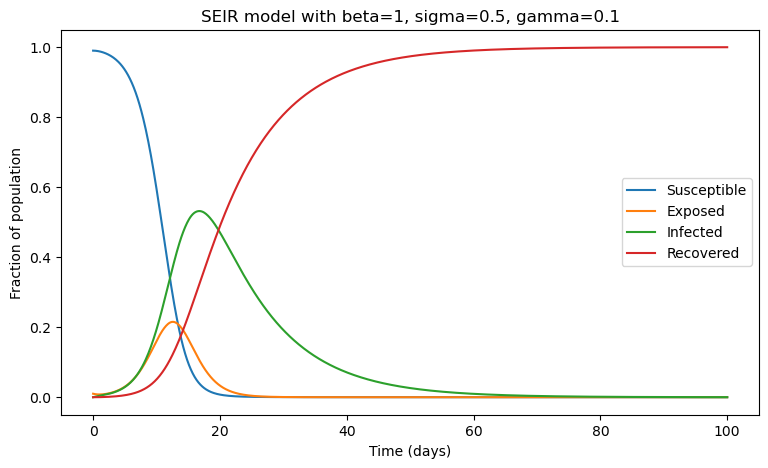

In [100]:
beta = 1
sigma = 0.5
gamma = 0.1

# Using the same y0 and times
sol = solve_ivp(solve_seir, [0, 100], y0, args=(beta, sigma, gamma), t_eval=times)

# Plotting the graph
s = sol.y[0]
e = sol.y[1]
i = sol.y[2]
r = sol.y[3]
t = sol.t

# Sigma = 0.5
infected_sig['0.5'] = i

# Plot the graph to verify
plt.figure(6, figsize=(9, 5))
plt.plot(t, s, label='Susceptible')
plt.plot(t, e, label='Exposed')
plt.plot(t, i, label='Infected')
plt.plot(t, r, label='Recovered')

plt.xlabel('Time (days)')
plt.ylabel('Fraction of population')
plt.title('SEIR model with beta=1, sigma=0.5, gamma=0.1')
plt.legend()
plt.show()

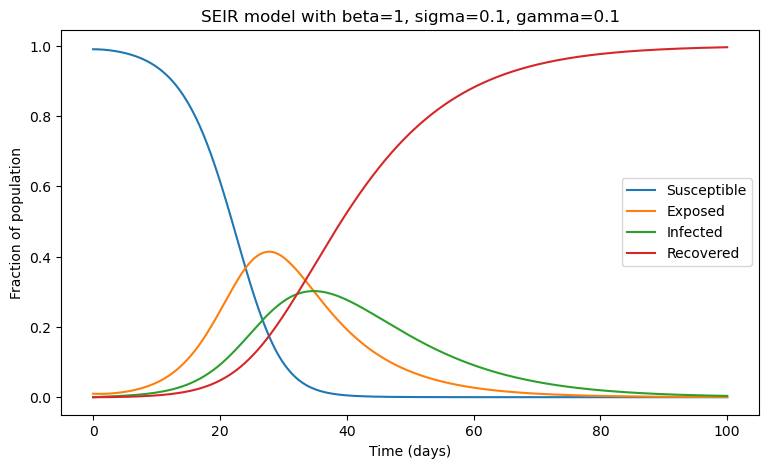

In [101]:
beta = 1
sigma = 0.1
gamma = 0.1

# Using the same y0 and times
sol = solve_ivp(solve_seir, [0, 100], y0, args=(beta, sigma, gamma), t_eval=times)

# Plotting the graph
s = sol.y[0]
e = sol.y[1]
i = sol.y[2]
r = sol.y[3]
t = sol.t

# Sigma = 0.5
infected_sig['0.1'] = i

# Plot the graph to verify
plt.figure(7, figsize=(9, 5))
plt.plot(t, s, label='Susceptible')
plt.plot(t, e, label='Exposed')
plt.plot(t, i, label='Infected')
plt.plot(t, r, label='Recovered')

plt.xlabel('Time (days)')
plt.ylabel('Fraction of population')
plt.title('SEIR model with beta=1, sigma=0.1, gamma=0.1')
plt.legend()
plt.show()

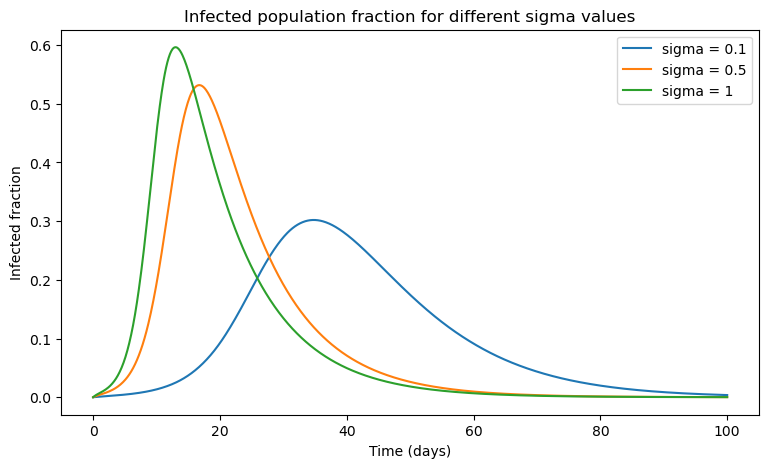

In [102]:
plt.figure(8, figsize=(9, 5))

for key in sorted(infected_sig, key=float):
    plt.plot(t, infected_sig[key], label=f"sigma = {key}")

plt.xlabel("Time (days)")
plt.ylabel("Infected fraction")
plt.title("Infected population fraction for different sigma values")
plt.legend()
plt.show()

Now, we will experiment with different initial base values, using the same times variable and the values of parameters given by the brief at the start.

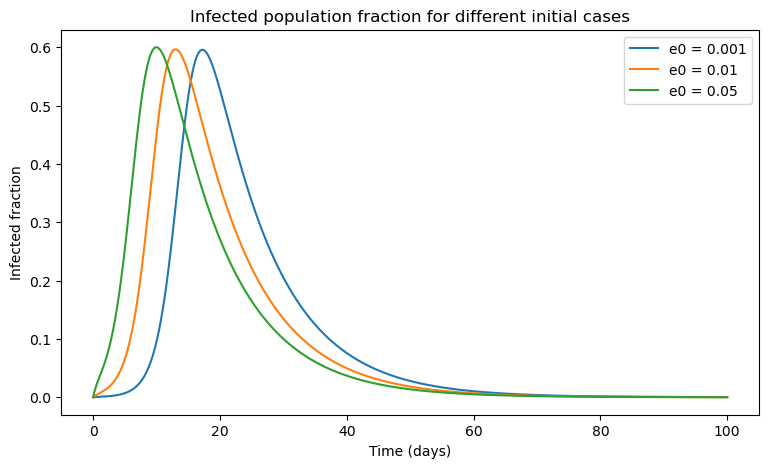

In [103]:
initial_cases = {"e0 = 0.001": [0.999, 0.001, 0.0, 0.0],
         "e0 = 0.01": [0.99, 0.01, 0.0, 0.0],
         "e0 = 0.05": [0.95, 0.05, 0.0, 0.0]
        }

beta = 1.0
sigma = 1.0
gamma = 0.1

plt.figure(9, figsize=(9, 5))

for label, y0 in initial_cases.items():
    sol = solve_ivp(solve_seir, [0, 100], y0, args=(beta, sigma, gamma), t_eval=times)
    i = sol.y[2]
    plt.plot(sol.t, i, label=label)

plt.xlabel("Time (days)")
plt.ylabel("Infected fraction")
plt.title("Infected population fraction for different initial cases")
plt.legend()
plt.show()